## **IN4640 Assignment 2**

## **Question 01**

### **Part (a)**

**Total Least Squares fitting using only first line points**

I use only the first line, meaning columns x1 and y1.

Total Least Squares minimizes the perpendicular distance to the line.
I use SVD to compute the best fitting line.

The general line equation is **ax + by + c = 0**

**For Total Least Squares:**

01. Take the points (x1, y1)

02. Compute centroid

03. Subtract centroid

04. Apply SVD

05. The line direction is the singular vector corresponding to the smallest singular value

06. Convert to line parameters

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np

# Load data
D = np.genfromtxt("/content/drive/MyDrive/MachineVision_Assignment_2/lines.csv", delimiter=",", skip_header=1)

# First line points
x1 = D[:, 0]
y1 = D[:, 3]

points = np.column_stack((x1, y1))

# Compute centroid
centroid = np.mean(points, axis=0)

# Subtract centroid
points_centered = points - centroid

# SVD
U, S, Vt = np.linalg.svd(points_centered)

# Line direction = last singular vector
direction = Vt[-1]

a = direction[0]
b = direction[1]

# Compute c using centroid
c = - (a * centroid[0] + b * centroid[1])

print("Total Least Squares Line Parameters")
print("a =", a)
print("b =", b)
print("c =", c)

Total Least Squares Line Parameters
a = 0.7735616496467872
b = -0.6337210539312556
c = -3.7941922108458135


### **Part (b)**

RANSAC to detect three lines

now use all points

x1, x2, x3
y1, y2, y3

RANSAC procedure:

01. Randomly sample two points

02. Fit a line

03. Compute distances of all points to the line

04. Count inliers under a threshold

05. Keep the model with highest consensus

06. Remove inliers

07. Repeat to find remaining lines

In [5]:
import random

# Prepare all points
X_cols = D[:, :3]
Y_cols = D[:, 3:]

X_all = X_cols.flatten()
Y_all = Y_cols.flatten()

points = np.column_stack((X_all, Y_all))

def fit_line(p1, p2):
    x1, y1 = p1
    x2, y2 = p2
    
    a = y1 - y2
    b = x2 - x1
    c = x1*y2 - x2*y1
    
    norm = np.sqrt(a*a + b*b)
    return a/norm, b/norm, c/norm

def distance(a, b, c, x, y):
    return abs(a*x + b*y + c)

def ransac(points, threshold=0.1, iterations=1000):
    best_inliers = []
    best_model = None
    
    for _ in range(iterations):
        idx = np.random.choice(len(points), 2, replace=False)
        p1, p2 = points[idx]
        
        a, b, c = fit_line(p1, p2)
        
        inliers = []
        for i, (x, y) in enumerate(points):
            if distance(a, b, c, x, y) < threshold:
                inliers.append(i)
        
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_model = (a, b, c)
    
    return best_model, best_inliers

remaining_points = points.copy()
models = []

for i in range(3):
    model, inliers = ransac(remaining_points)
    models.append(model)
    
    remaining_points = np.delete(remaining_points, inliers, axis=0)

for i, (a, b, c) in enumerate(models):
    print(f"Line {i+1} parameters:")
    print("a =", a)
    print("b =", b)
    print("c =", c)
    print()

Line 1 parameters:
a = -0.8288937039565168
b = 0.5594061382763387
c = 3.7154693200290847

Line 2 parameters:
a = -0.7329218086573315
b = 0.6803128856595808
c = -0.649798674637577

Line 3 parameters:
a = -0.3478353090506647
b = -0.937555650496347
c = 1.9514854523416527



**Visualization**

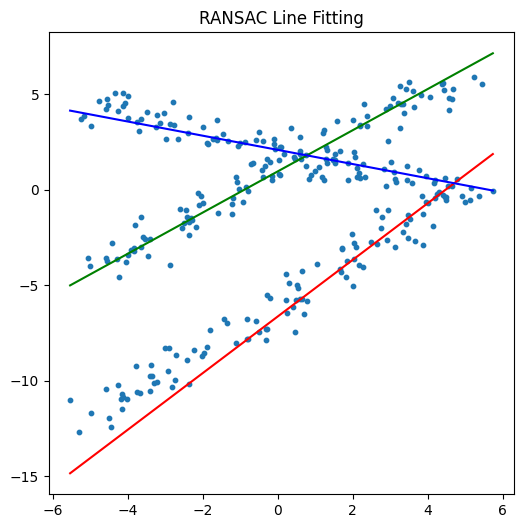

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

colors = ['r','g','b']

for i, (a, b, c) in enumerate(models):
    xs = np.linspace(min(X_all), max(X_all), 100)
    ys = (-a*xs - c) / b
    plt.plot(xs, ys, colors[i])

plt.scatter(X_all, Y_all, s=10)
plt.title("RANSAC Line Fitting")
plt.show()